# Impact of $A$ on dipole + $m_5$ map generation

The goal of this notebook is to generate tha data to study the impact of A on the injected dipole measurement when the $m_5$ is added.

In [1]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
%matplotlib inline
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.table import Table
import fitsio

from simulMap import *
from fitMap import *
from utile_fitsFile import *
from lumMag_sampling import *
from mappers import CountMapper, DepthMapper
from spectra import Spectrum
from generators import Generator

In [2]:
#sources:
NSource_px_th = int(1e6)
#print("Total number of sources in the entire sky : {}".format(NSource_px_th*npix))
print("Theorical number of sources in one pixel : {}".format(NSource_px_th))

Theorical number of sources in one pixel : 1000000


## $m_5$ magnitude

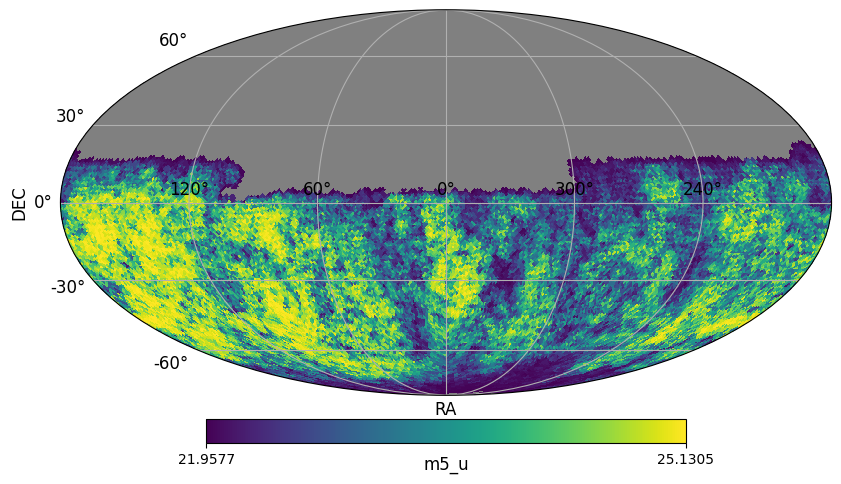

In [3]:
DIR_m5 = '../data/'
FILE = DIR_m5 + "baseline_v5.0.0_10yrs_summary.hdf5"
dm = DepthMapper.read_hdf(FILE)
dm.select_year(1)
band = 'u'
dm.select_band(band)
dm.set_mask()
dm.plot()

## Reference spectrum

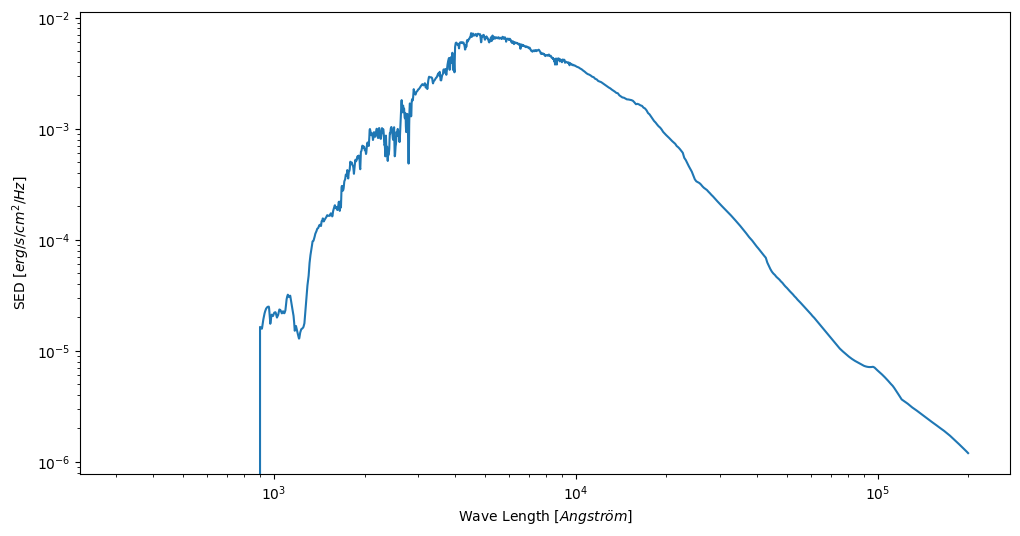

In [4]:
DIR_SED = "../data/data SED/SED GAL/COSMOS/"
FILE_SED = "Ell1_A_0"
file = DIR_SED + FILE_SED + ".sed"
refSpectum = Spectrum.read_sed(file)
refSpectum.plot(loglog=True, title="");

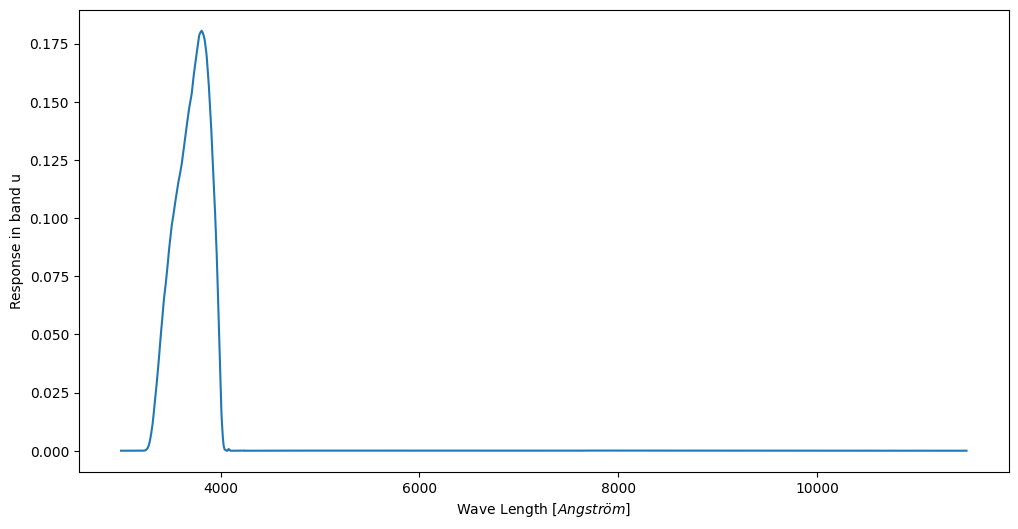

In [5]:
file_band = f"../data/data LSST/total_{band}.dat"
responseSpectrum = Spectrum.read_sed(file_band, yname=f"Response in band {band}", yunit="")
responseSpectrum.wavelength = responseSpectrum.wavelength*10
responseSpectrum.plot(loglog=False, title="");

In [6]:
_, response = refSpectum.get_surrounding(responseSpectrum)
response = response.mean(axis=0)
L_bandRatio = refSpectum.ratio_integrate(response)
print(f"SED band {band} ratio : {L_bandRatio}")

SED band u ratio : 0.013291492416839587


## Importing $N_{th}$ map

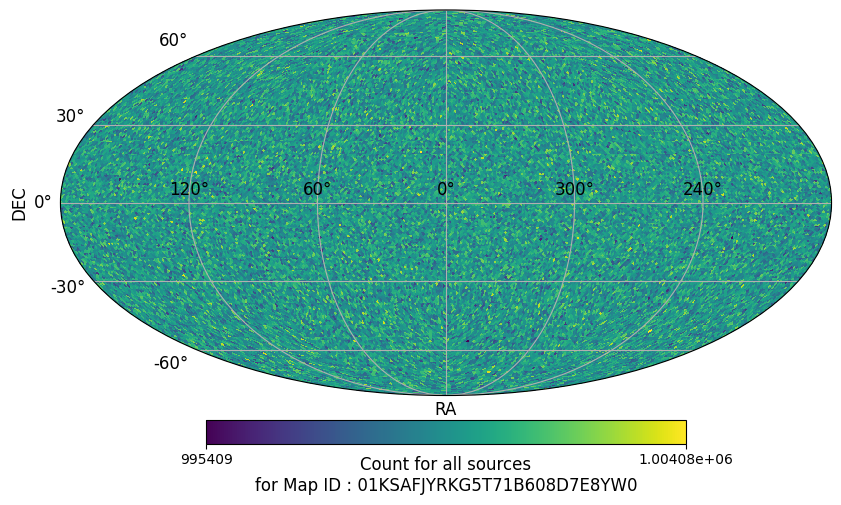

In [7]:
DIR_Nth = "Catalog_m5/Catalog_m5Nth/"
sufix = "NthPoisson"
file_Nth = DIR_Nth + sufix + '.fits'

count_thMapper = CountMapper.read_map_fits(file_Nth, idx=0, HDU='Nth_1e6', unitSuffix="all sources") #first Nth map
count_thMapper.plot()

## Importing bolometric data file

In [8]:
DIR_cat = "Catalog_m5/Catalog_m5Ratio/"
sufix = "testRatio"
file_cat = DIR_cat + sufix + '.fits'

dataN, data_ID = read_lumMag_fits(file_cat, 0, L_bandRatio=L_bandRatio, to_band=band)
dataN

z,dL,L,M,m,L_u,M_u,m_u
,Mpc,solLum,,,solLum,solLum,solLum
float64,float64,float64,float64,float64,float64,float64,float64
1.014542326432987,7027.145682378759,30645546.713645894,-13.885918433823983,30.34797635193339,407325.0517543277,-9.19485280341342,35.03904198234395
0.7363209110631574,4734.488512540824,2677336894.761015,-18.73925755696431,24.63710777876085,35585803.034040876,-14.04819192655375,29.328173409171413
0.8083768640688359,5309.647095345624,25510623.16818487,-13.686802668986099,29.938525614728903,339074.2543887815,-8.99573703857554,34.62959124513946
0.45044390448429966,2612.4876463369646,15778842.982701296,-13.165187886180528,28.920083341203785,209724.3718510768,-8.474122255769968,33.61114897161435
0.4987659532367315,2950.87540205728,12663883.576797798,-12.926417273155431,29.423337087896755,168321.9125287473,-8.235351642744869,34.11440271830732
0.8516695348807279,5661.8510749809375,125990258.58744024,-15.42084241824489,28.34394979089506,1674598.5666106206,-10.72977678783433,33.035015421305616
0.8438439425794242,5597.832695085243,794616713.3066007,-17.42039423851022,26.319705333348903,10561642.019208679,-12.729328608099655,31.01077096375947
0.32696617180733534,1792.138316712811,169180714.42846972,-15.740877136493586,25.5259804902122,2248664.182901509,-11.049811506083023,30.21704612062276


## Ratio and detected map creation

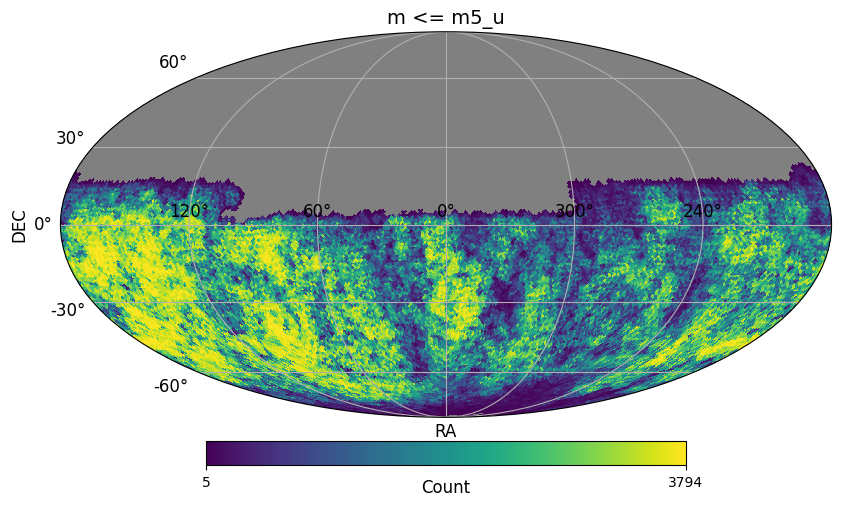

In [9]:
_, hpmap_band = dm._get_band_map(band)
NSource_px = cut_m52map(dataN[f"m_{band}"], hpmap_band)
countMapper = CountMapper.from_map(NSource_px)
countMapper.set_mask()
countMapper.plot("Masked", norm="hist", title= f"m <= m5_{band}")

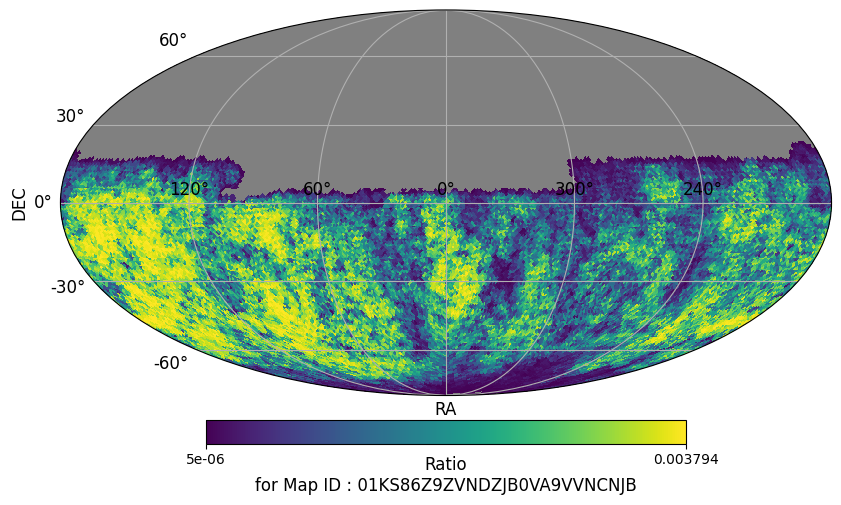

In [10]:
ratioMapper = CountMapper.from_map(countMapper.map/NSource_px_th)
ratioMapper._set_instance_settingsPlot(unit = 'Ratio')
ratioMapper.set_mask()
ratioMapper.set_mapID(data_ID)
ratioMapper.plot("Masked", norm="hist")

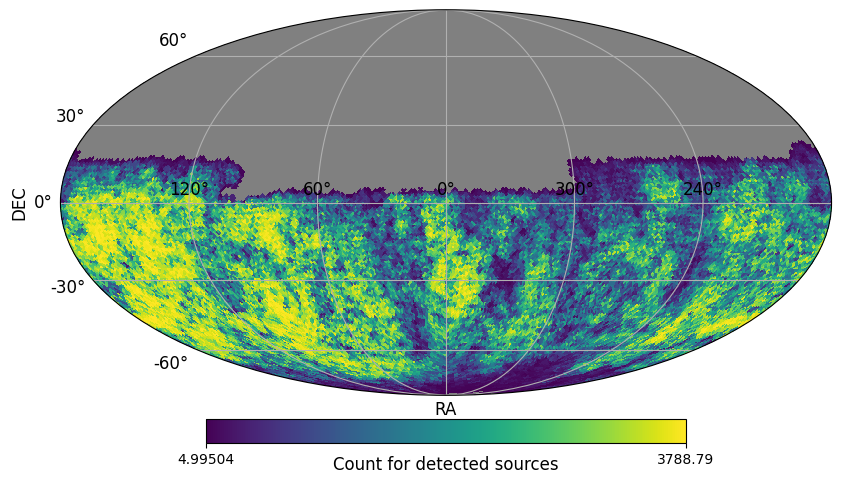

In [11]:
countDetectedMapper = CountMapper.from_map(count_thMapper.map * ratioMapper.map)
countDetectedMapper._set_suffixTextPlot(unit = "detected sources")
countDetectedMapper.set_mask()
countDetectedMapper.plot("Masked", norm="hist")

## Importing clustering

/home/victoria/miniconda3/envs/M2Stage/lib/python3.10/site-packages/pyccl/errors.py:22: CCLWarning: Nchi must be a positive integer. Setting to match tracer with fewest chi samples.
  warnings_builtin.warn(*args, **kwargs)
/home/victoria/miniconda3/envs/M2Stage/lib/python3.10/site-packages/pyccl/errors.py:22: CCLWarning: chi_min must be greater than zero.Setting to default 1e-6 Mpc.
  warnings_builtin.warn(*args, **kwargs)


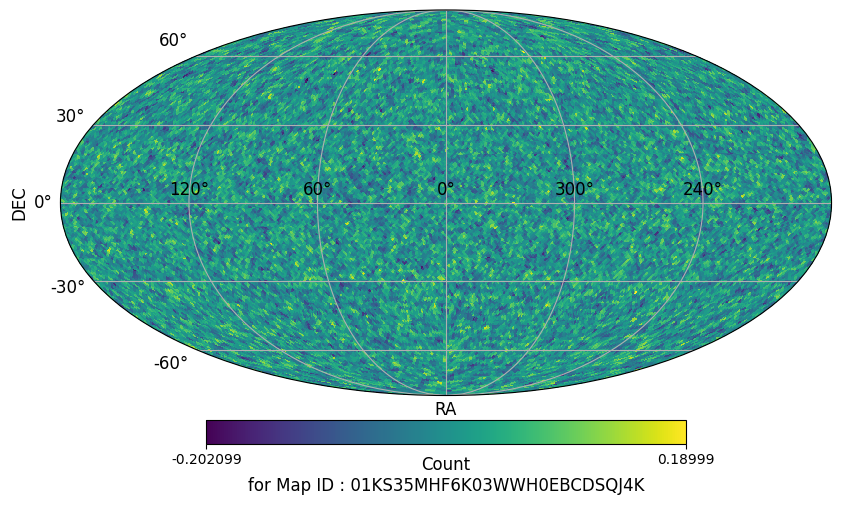

In [12]:
DIR_cl = "Fit_Clusters/Clusters_NoDipole/Clusters_NoDipole_"
sufix = "zmin0.1"
clFile = DIR_cl + sufix + '.fits'

clMapper = CountMapper.read_map_fits(clFile, idx=0, nest=False) #first clustering map
clMapper = clMapper.invert_nest()
clMapper.plot()

generator = Generator(nside = clMapper.nside, nest = clMapper.nest)

## Dipole creation

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 3.456e-07 (χ²/ndof = 0.0)  │              Nfcn = 262              │
│ EDM = 3.46e-07 (Goal: 0.0002)    │            time = 2.3 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ A    │   0.100   │   0.002   │   -0.002   │   0.002    │    0    │    1    │       │
│ 1 │ ra   │  168.00   │   0.23    │   -0.23    │    0.23    │    0    │   360   │       │
│ 2 │ dec  │   -7.0    │    0.4    │    -0.4    │    0.4     │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │  -0.002   │   0.002   │   -0.23   │   0.23    │   -0.4    │    0.4    │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬────────────────────────────┐
│     │        A       ra      dec │
├─────┼────────────────────────────┤
│   A │ 4.07e-06    -0e-6     0e-6 │
│  ra │    -0e-6   0.0509    -0.03 │
│ dec │     0e-6    -0.03    0.134 │
└─────┴────────────────────────────┘

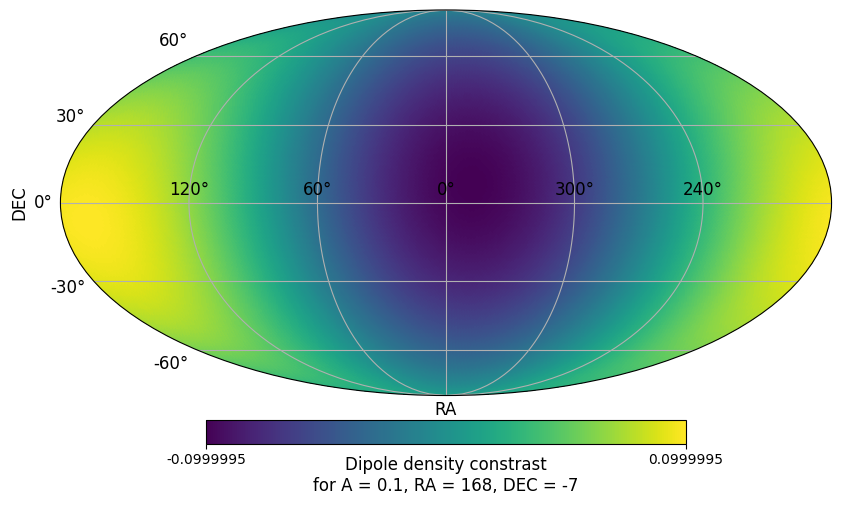

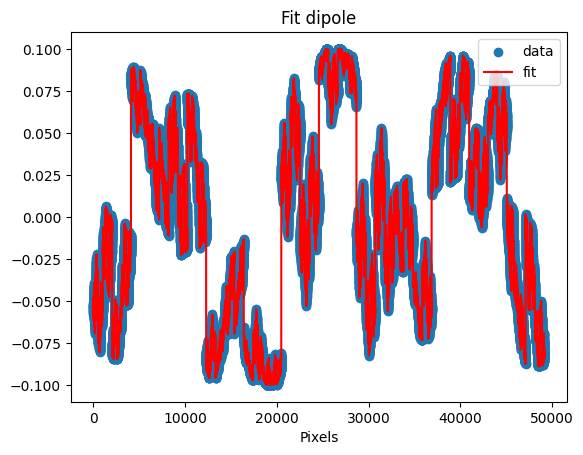

In [13]:
nest = True
A, ra, dec = 0.1, 168, -7
dipoleMapper = generator.generate_dipoleContrast(A, ra, dec)

init =  (1, 100, 0)
dipoleMapper.fit_dipole("", init, fit_monop=False)

## Applying dipole

### Study of $A$

In [14]:
def get_m5DipMonop(A, ra=ra, dec=dec, M=NSource_px_th, add_cl=False, poissNoise=False, densField=False):
    if add_cl: contrastMapper = generator.generate_dipoleContrast(A, ra, dec, clMapper=clMapper, unit = f"Clustering and dipole density contrast for A = {A}")
    else: contrastMapper = generator.generate_dipoleContrast(A, ra, dec, clMapper=None, unit = f"Dipole density contrast for A = {A}")
    countObservedMapper = generator.generate_monopole(countDetectedMapper.map, contrastMapper=contrastMapper, unit = f"Count for observed sources\ndipole A = {A}, and monopole N* = {M}")
    hpmapMasked = dm._select_useMap(f'{band}Masked')
    countObservedMapper.set_mask(hpmapMasked.mask)

    countCorrectedMapper = CountMapper.from_map(countObservedMapper.map / ratioMapper.map)
    countCorrectedMapper.fillna()
    
    if poissNoise: countCorrectedMapper = countCorrectedMapper.get_poisson_noise()
    if densField: countCorrectedMapper = countCorrectedMapper.get_densField()
    countCorrectedMapper._set_suffixTextPlot(unit = f"corrected sources\ndipole A = {A}, and monopole N* = {M}")
    countCorrectedMapper.set_mask()

    return countCorrectedMapper, contrastMapper


def get_compute(A, ra=ra, dec=dec, M=NSource_px_th, init=(1e6, 1, 100, 0), fixed=[], add_cl=False, poissNoise=False, densField=False):
    monopMapper, contrastMapper = get_m5DipMonop(A, ra, dec, M, add_cl, poissNoise, densField)
    m = monopMapper.fit_dipole("Masked", init, plot_fig=False, plot_map=False, verbose=False, fixed=fixed)
    
    add_param = {"Nth_ID": count_thMapper.ID, "Ratio_ID": ratioMapper.ID, "BAND": band}
    add_param = get_add_param_minuit(m, M, A, ra, dec, add_param=add_param)
    if add_cl: add_param["Cluster_ID"] = contrastMapper.ID
    
    if poissNoise: mapID = monopMapper.ID
    else: mapID = "NaN"
    dic_param = get_dicParam_minuit(m, mapID, add_param=add_param)
    return m, dic_param, monopMapper



add_cl = True
densField = False
poissNoise = True
Alist = np.logspace(-3, -1, 50)

M, init = NSource_px_th, (NSource_px_th, 1, 100, 0)
fixed = []

dfMinuit, mapList, IDlist = [], [], []

for i in range(len(Alist)):
    if i % 10 == 0: print(f'i = {i}', end = '\t')
    Atest = Alist[i]
    m, dic_param, monopMapper = get_compute(Atest, M=M, init=init, fixed=fixed, add_cl=add_cl, poissNoise=poissNoise, densField=densField)
    dfMinuit.append(dic_param)
    if poissNoise:
        mapList.append(monopMapper._select_useMap(""))
        IDlist.append(str(monopMapper.ID))
print('\nFit complete.')

dfMinuit = pd.concat(dfMinuit, ignore_index=True)
dicMaps = get_dicMaps(IDlist, mapList)
dfMinuit

i = 0	

/tmp/ipykernel_63119/4245790441.py:8: RuntimeWarning: invalid value encountered in divide
  countCorrectedMapper = CountMapper.from_map(countObservedMapper.map / ratioMapper.map)


i = 10	i = 20	i = 30	i = 40	
Fit complete.


,Map_ID,N*,N*_init,N*_err,N*_fixed,N*_limit_0,N*_limit_1,A,A_init,A_err,...,dec_limit_1,valid,Nth_ID,Ratio_ID,BAND,N*_true,A_true,ra_true,dec_true,Cluster_ID
0,01KT6HQK3YSZH63K8Z55YH1XW5,997973.454164,1000000.0,8.831160,False,0.0,inf,0.001796,1.0,0.000010,...,90.0,True,01KSAFJYRKG5T71B608D7E8YW0,01KS86Z9ZVNDZJB0VA9VVNCNJB,u,1000000,0.001000,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K
1,01KT6HQST6FTC348Y4EMSZG7ZW,997988.140249,1000000.0,8.832036,False,0.0,inf,0.001907,1.0,0.000010,...,90.0,True,01KSAFJYRKG5T71B608D7E8YW0,01KS86Z9ZVNDZJB0VA9VVNCNJB,u,1000000,0.001099,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K
2,01KT6HQXTCCP3F1YY33ZHYCCWJ,997981.992884,1000000.0,8.760397,False,0.0,inf,0.001986,1.0,0.000010,...,90.0,True,01KSAFJYRKG5T71B608D7E8YW0,01KS86Z9ZVNDZJB0VA9VVNCNJB,u,1000000,0.001207,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K
3,01KT6HR3VYNTQ5S9BNXBDQR45T,997975.691615,1000000.0,8.832254,False,0.0,inf,0.002084,1.0,0.000010,...,90.0,True,01KSAFJYRKG5T71B608D7E8YW0,01KS86Z9ZVNDZJB0VA9VVNCNJB,u,1000000,0.001326,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K
4,01KT6HR86AXZRFJ1K05XH2E6XZ,997996.092174,1000000.0,8.832551,False,0.0,inf,0.002196,1.0,0.000010,...,90.0,True,01KSAFJYRKG5T71B608D7E8YW0,01KS86Z9ZVNDZJB0VA9VVNCNJB,u,1000000,0.001456,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K
5,01KT6HRCXDMMSN877GP0JXDQET,997988.884228,1000000.0,8.832899,False,0.0,inf,0.002309,1.0,0.000010,...,90.0,True,01KSAFJYRKG5T71B608D7E8YW0,01KS86Z9ZVNDZJB0VA9VVNCNJB,u,1000000,0.001600,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K
6,01KT6HRHJE1CJ7QTPRZQ5YEPHQ,997975.287002,1000000.0,8.833649,False,0.0,inf,0.002451,1.0,0.000010,...,90.0,True,01KSAFJYRKG5T71B608D7E8YW0,01KS86Z9ZVNDZJB0VA9VVNCNJB,u,1000000,0.001758,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K
7,01KT6HRP00HP59WDH1YZFT92TE,997994.480985,1000000.0,8.807309,False,0.0,inf,0.002625,1.0,0.000010,...,90.0,True,01KSAFJYRKG5T71B608D7E8YW0,01KS86Z9ZVNDZJB0VA9VVNCNJB,u,1000000,0.001931,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K
8,01KT6HRTJYY0P2BS1V1HDRXZ6J,997984.094783,1000000.0,8.836319,False,0.0,inf,0.002804,1.0,0.000010,...,90.0,True,01KSAFJYRKG5T71B608D7E8YW0,01KS86Z9ZVNDZJB0VA9VVNCNJB,u,1000000,0.002121,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K
9,01KT6HRZTTMRH0BJFCC847VKZ3,998430.208214,1000000.0,1.049543,False,0.0,inf,0.001302,1.0,0.000006,...,90.0,False,01KSAFJYRKG5T71B608D7E8YW0,01KS86Z9ZVNDZJB0VA9VVNCNJB,u,1000000,0.002330,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K


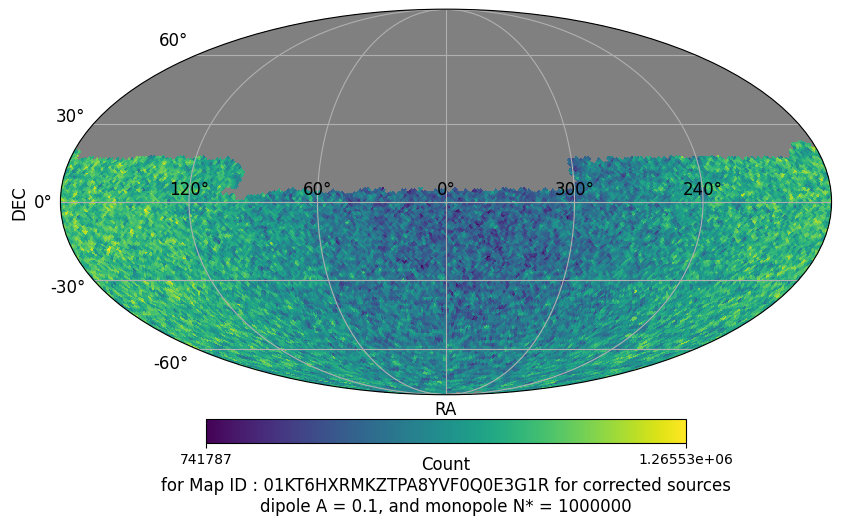

In [15]:
monopMapper.plot('Masked')

#### Saving data

In [16]:
output_path = "Fit_m5/m5_Dipole/m5_Dipole_"
if poissNoise: suffix_poiss = "_poissVar"
else: suffix_poiss = ""
if add_cl: suffix = "Param_study_Cluster"
else: suffix = "Param_study_NoCluster"
outputfile = output_path + suffix + suffix_poiss +".fits"

HDU_target='A_STUDY'

header_global = {'MAP_TYPE': 'm5_Observed', 'INJECT_DIPOLE': True, 'INJECT_CLUSTERING': add_cl, 'POISSON_NOISE' : poissNoise}
if poissNoise: dicMaps_fiterd = get_save_dicMaps(dicMaps, outputfile, HDU_target=f'{HDU_target}_MAPS_{band}', header_global=header_global)
dfMinuit_filtered = get_save_fit_dfMinuit(dfMinuit, outputfile, HDU_target=HDU_target, header_global=header_global)

Coulndn't find HDU A_STUDY_MAPS_u in the data ; creating one.
Saving maps in Fit_m5/m5_Dipole/m5_Dipole_Param_study_Cluster_poissVar.fits
Saving complete.


/home/victoria/Travaux_Jupyter_Ububtu/M2Stage_JohannGit/M2_Stage_Code/Simulation/fitMap.py:282: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(False, inplace=True)


Saving Dataframe results in Fit_m5/m5_Dipole/m5_Dipole_Param_study_Cluster_poissVar.fits
Saving complete.
